# Background

- **Author**: `黃書佑`
- **Created At**: `2026-05-14`
- **Research Motivation and Context (why are we interested in the findings?)：**
    - 對客戶進行分群，以精準分配最適合各客群的飲品，進而優化行銷策略並提升轉化率。
    - 探討為何管理層傾向提供「指定產品禮券」而非「全品項折扣」的商業邏輯，也是本次研究的核心動機。
- **Main Findings and Takeaways：**
    - 產品關聯性：數據顯示特定品項間存在強烈負相關，如「純咖啡與奶茶」以及「冰沙與調味茶」，反映出顧客口味具有明顯的排他性。
    - 年齡層偏好差異：20 歲以下客群對「冰沙」有極高偏好（佔比 77.7%），而 51 歲以上客群則集中於「調味茶」（佔比 68.6%），年齡是區分客群最強力的特徵。
    - 禮券品項的策略定位：目前指定的五種生日禮券飲品在總銷量排名中皆位於末端，但單價普遍較高。這證實了管理層傾向發放「高感知價值、低頻購買」的產品，以推廣新品或清理庫存。
    - 特徵有效性：探索性分析發現「消費時間」與「註冊年份」在各類別間分佈均勻，並非區分客群的有效變數。
- **Future Direciton：**
    - 分群建模：用 K-Means 演算法進行客戶分群，初步建議設定 K=5 以對應五種生日禮券飲品。
    - 特徵矩陣：在建模階段將優先採用「各類別購買佔比」作為特徵，並納入年齡層、性別與會員等級。 
    - 標籤化與推薦：分析各分群的特徵重心並賦予具商業意義的標籤（如：Morning Coffee Seeker），最終為每個分群推薦最適配的生日禮券品項 。

In [1]:
# for data cleaning and processing
import numpy as np
import pandas as pd

# for drawing
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
%matplotlib inline

In [2]:
# --- Mac 中文顯示設定 ---
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## Member data

In [3]:
members = pd.read_csv('../clean/members.csv')
members.head()

,member_id,name,gender,register_date,birthday,card_level,age,register_year
0,1,Jason Cheng,男,2020-01-30,1943-05-30,金,83,6
1,2,郭子瑜,女,2019-03-17,2004-06-30,金,22,7
2,3,賴芷嫣,女,2023-11-30,2001-11-23,銀,25,3
3,4,Emily Liu,女,2022-09-27,1976-02-26,鑽石,50,4
4,5,Linda Susan Wang,女,2024-05-01,2000-04-19,金,26,2


In [4]:
print(f"總共有{len(members)}筆會員資料。")
print(f"會員年紀最低為{members['age'].min()}，最高為{members['age'].max()}。")
print(f"會員註冊年份最低為{members['register_year'].min()}，最高為{members['register_year'].max()}。")

總共有20000筆會員資料。
會員年紀最低為14，最高為88。
會員註冊年份最低為2，最高為7。


In [5]:
members['age'].describe()

count    20000.000000
mean        39.701750
std         22.174875
min         14.000000
25%         22.000000
50%         32.000000
75%         53.000000
max         88.000000
Name: age, dtype: float64

/var/folders/wm/pszd7fkd3h547vjckdbqkbd00000gp/T/ipykernel_29103/1720744513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=members, x='gender', ax=axes[0, 0], palette='Set2')
/var/folders/wm/pszd7fkd3h547vjckdbqkbd00000gp/T/ipykernel_29103/1720744513.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=members, x='card_level', ax=axes[0, 1], palette='Set2')
/var/folders/wm/pszd7fkd3h547vjckdbqkbd00000gp/T/ipykernel_29103/1720744513.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=members, x='register_year', ax=a

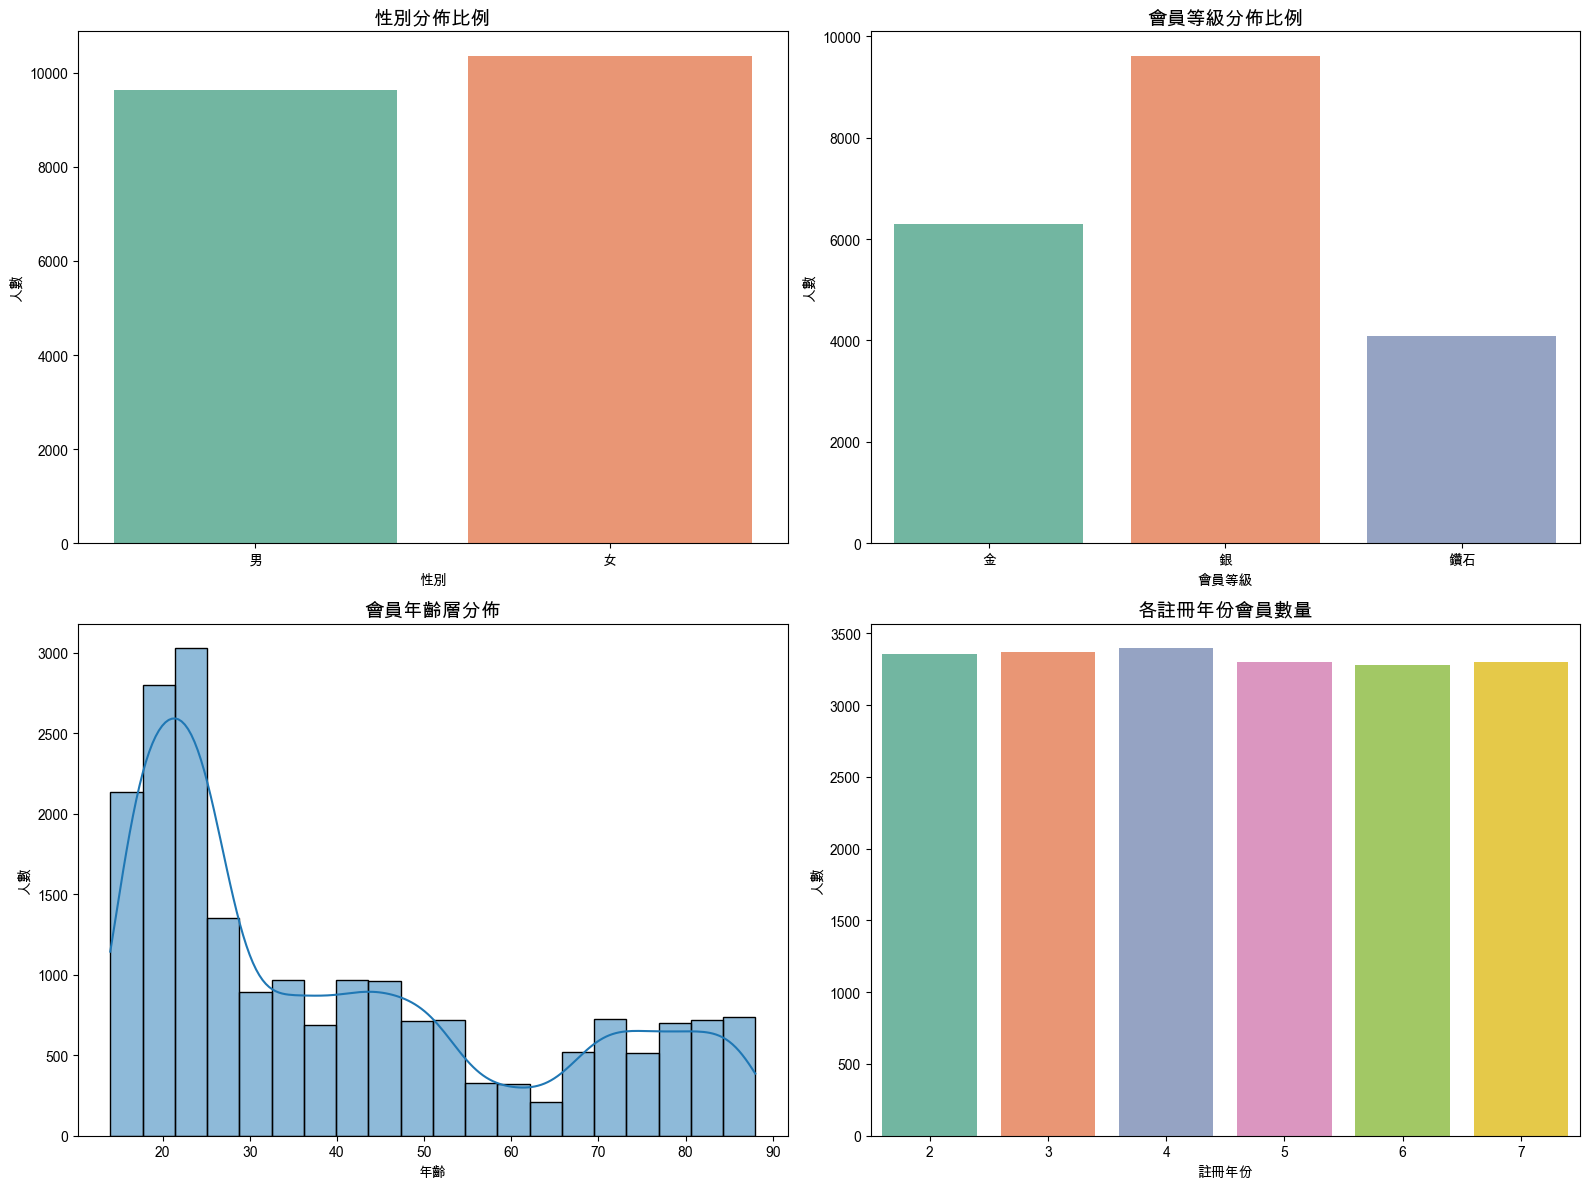

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. 左上象限：性別比例 (長條圖計數) ---
sns.countplot(data=members, x='gender', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('性別分佈比例', fontsize=14)
axes[0, 0].set_xlabel('性別')
axes[0, 0].set_ylabel('人數')

# --- 2. 右上象限：各會員等級比例 ---
sns.countplot(data=members, x='card_level', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('會員等級分佈比例', fontsize=14)
axes[0, 1].set_xlabel('會員等級')
axes[0, 1].set_ylabel('人數')

# --- 3. 左下象限：各年齡層會員數量 ---
sns.histplot(data=members, x='age', bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('會員年齡層分佈', fontsize=14)
axes[1, 0].set_xlabel('年齡')
axes[1, 0].set_ylabel('人數')

# --- 4. 右下象限：各註冊時間會員數量 ---
sns.countplot(data=members, x='register_year', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('各註冊年份會員數量', fontsize=14)
axes[1, 1].set_xlabel('註冊年份')
axes[1, 1].set_ylabel('人數')
axes[1, 1].tick_params(axis='x')

# --- 自動調整子圖間距並顯示 ---
plt.tight_layout()
plt.show()

### Findings

1. 年輕客群為絕對主力
 - 從左下角的年齡層分佈圖可見，會員年齡呈現明顯的右偏態分佈。最大的客群集中在 20~25 歲的年輕族群（大學生與初入職場的新鮮人），過了 30 歲之後人數呈現斷崖式下滑。這意味著品牌的行銷語彙、產品包裝與數位體驗應以「Z 世代」的喜好為核心。

2. 性別分佈均衡，女性微幅領先
 - 左上角的性別分佈顯示，女性會員數量略高於男性會員，整體男女比例相當均衡。在設計一般性促銷活動時，可兼顧兩性市場，不需過度偏向單一性別。

3. 金字塔型的會員忠誠度結構
 - 右上角的會員等級呈現健康的金字塔結構，這顯示多數會員仍處於基礎消費階段，未來行銷操作的重點可放在「如何設計誘因，促使龐大的銀卡會員升等至金卡」。

4. 穩定的獲客能力
 - 右下角顯示不同註冊年份的會員數量幾乎完全一致。代表品牌每年的「新客獲取量」或「留存率」極度穩定，沒有爆發性的成長，但也未見衰退。

## Sales data

In [7]:
sales = pd.read_csv('../clean/sales.csv')
sales.head()

,transaction_id,member_id,purchase_datetime,payment_method,category,product,size,price,hour
0,T00000002,3428,2024-01-01 08:00:01,電子支付,調味茶,櫻桃紅茶,L,120,8
1,T00000003,3428,2024-01-01 08:00:01,禮物卡,調味茶,檸檬茶,L,110,8
2,T00000004,3099,2024-01-01 08:00:04,現金,純咖啡,冷萃咖啡,L,140,8
3,T00000005,13482,2024-01-01 08:00:05,禮物卡,調味茶,櫻桃紅茶,L,120,8
4,T00000006,10752,2024-01-01 08:00:10,電子支付,奶茶,抹茶鮮奶,L,140,8


In [8]:
print(f"總共有{len(sales)}筆銷售資料。")
print(f"資料時間從{sales['purchase_datetime'].min()}到{sales['purchase_datetime'].max()}。")

總共有2846178筆銷售資料。
資料時間從2024-01-01 08:00:01到2024-12-28 19:59:53。


In [9]:
# --- 建立全域的色彩對照表 ---
all_categories = sorted(sales['category'].unique().tolist())
global_palette = dict(zip(all_categories, sns.color_palette('Set2', len(all_categories))))

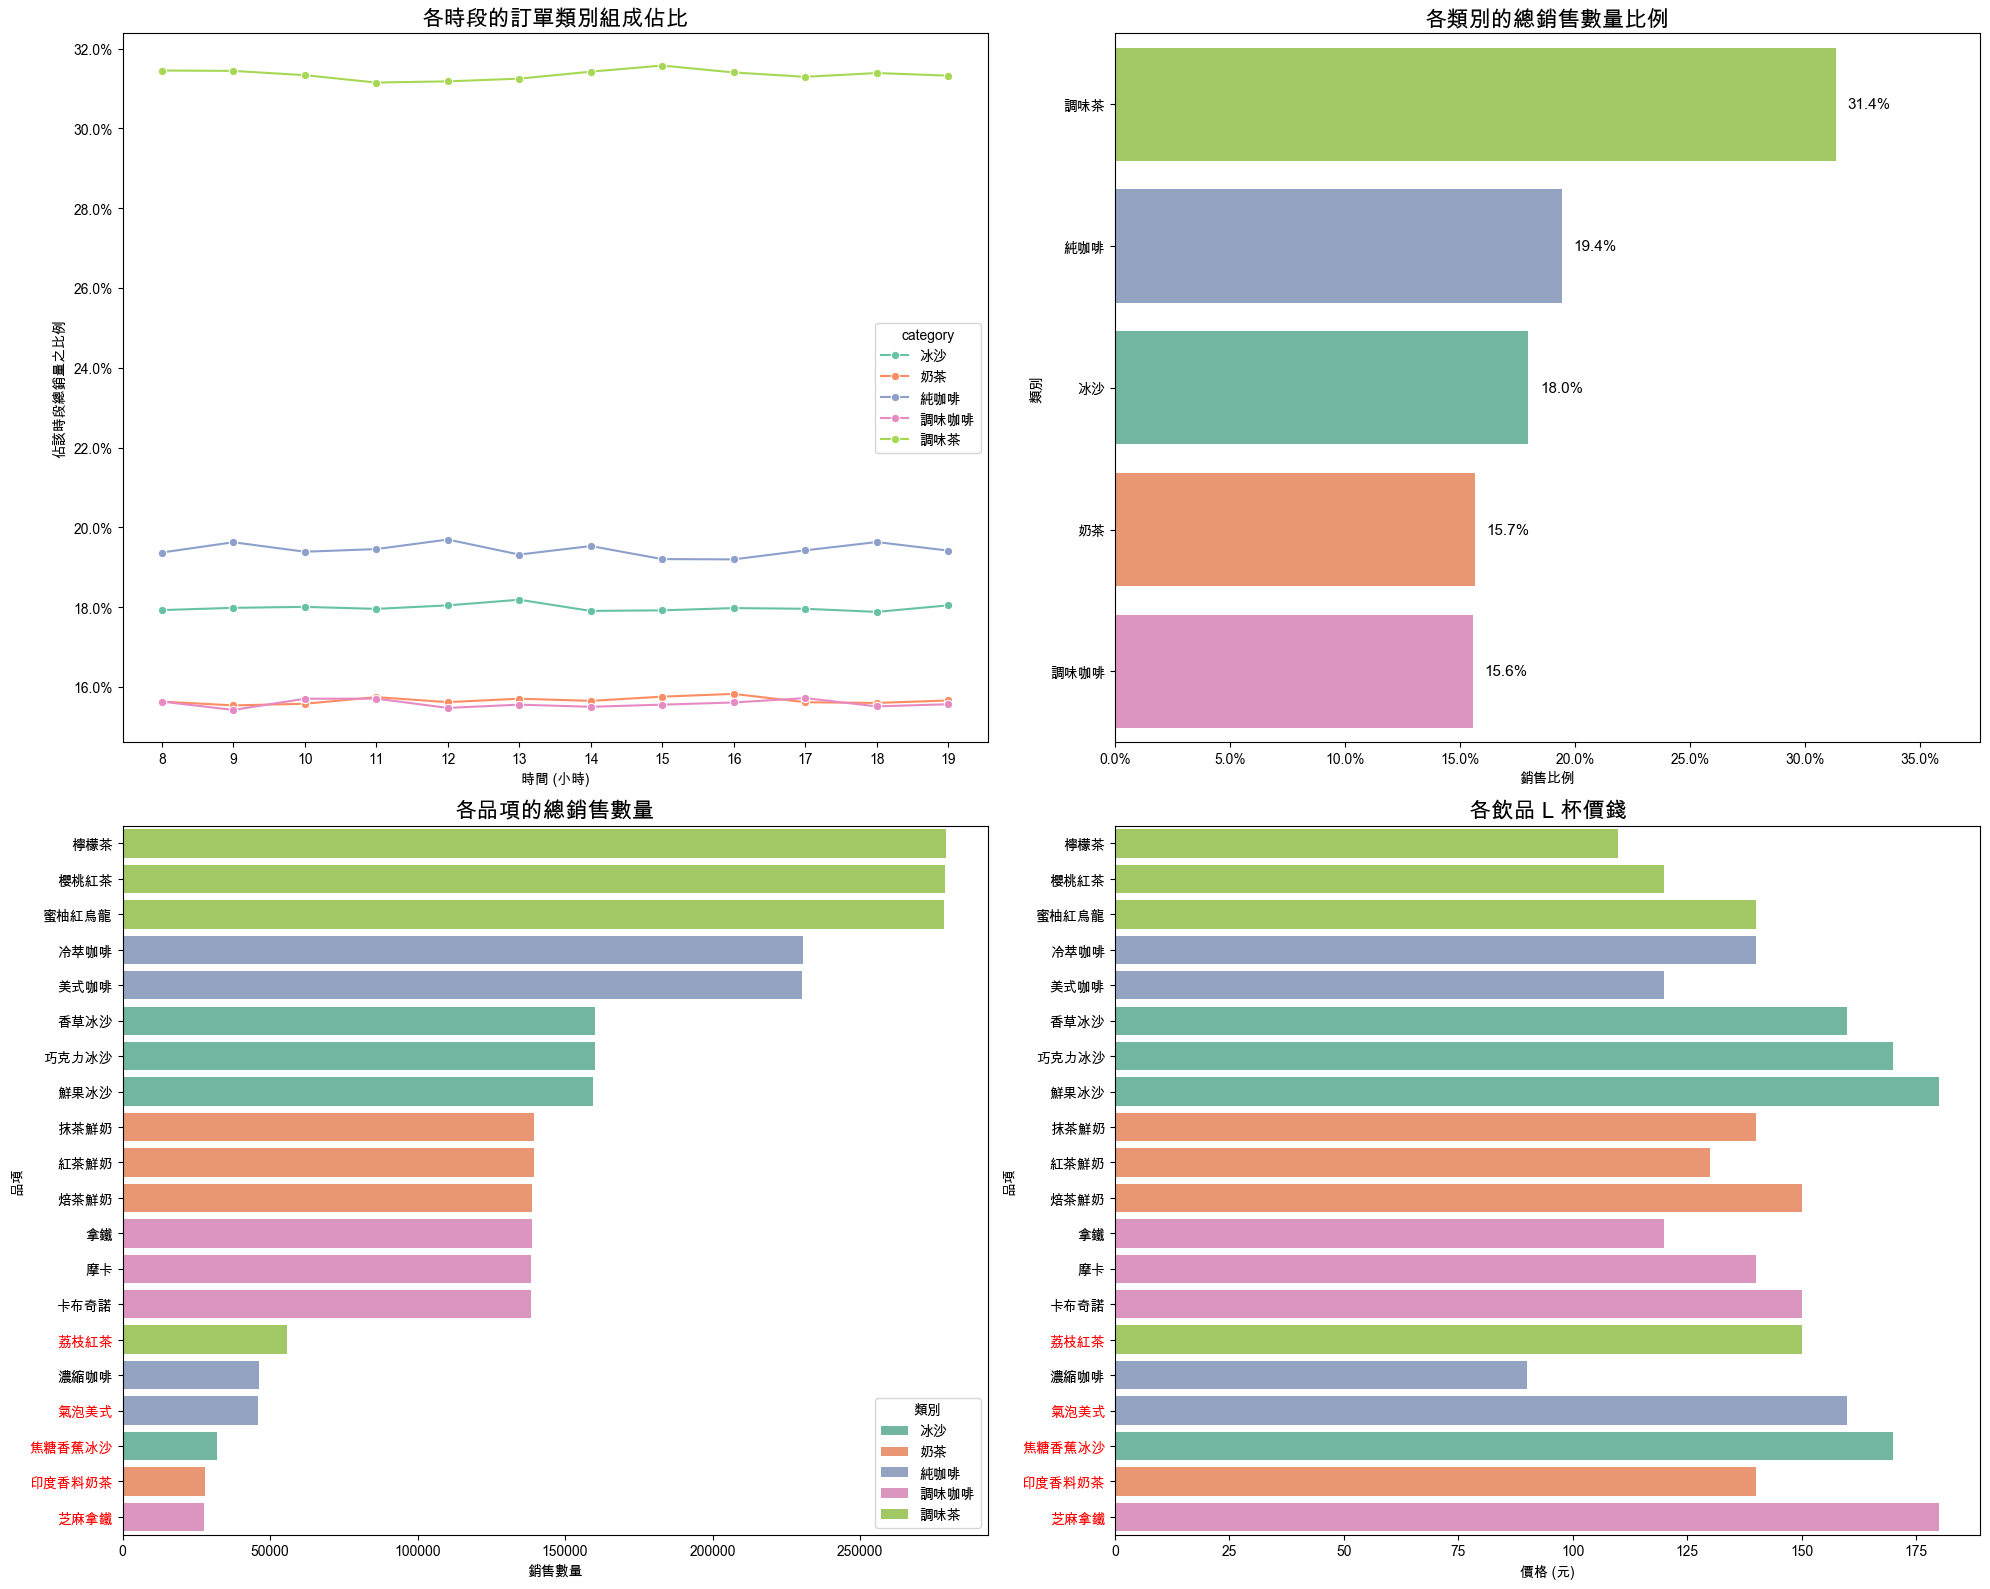

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- 象限一 (左上)：各時段的訂單類別組成佔比 ---
# 1. 先計算出 (小時, 類別) 的絕對銷售數量
hourly_cat_sales = sales.groupby(['hour', 'category']).size().reset_index(name='count')

# 2. 計算「每個小時的總銷量」
hourly_totals = hourly_cat_sales.groupby('hour')['count'].transform('sum')

# 3. 算出比例：(該小時該類別的銷量) / (該小時的所有類別總銷量)
hourly_cat_sales['proportion'] = hourly_cat_sales['count'] / hourly_totals

# 4. 繪製比例折線圖
sns.lineplot(
    data=hourly_cat_sales, 
    x='hour', 
    y='proportion', 
    hue='category', 
    palette=global_palette, 
    marker='o', 
    ax=axes[0, 0]
)

axes[0, 0].set_title('各時段的訂單類別組成佔比', fontsize=16)
axes[0, 0].set_xlabel('時間 (小時)')
axes[0, 0].set_ylabel('佔該時段總銷量之比例')

# 讓 Y 軸顯示為百分比格式
axes[0, 0].yaxis.set_major_formatter(PercentFormatter(1.0))

# 確保 X 軸顯示每一個小時的刻度
axes[0, 0].set_xticks(range(hourly_cat_sales['hour'].min(), hourly_cat_sales['hour'].max() + 1))

# --- 象限二 (右上)：各類別的總銷售數量比例 ---
# 計算各類別總銷量與比例，並由大到小排序
cat_counts = sales.groupby('category').size().reset_index(name='count')
total_sales = cat_counts['count'].sum()
cat_counts['proportion'] = cat_counts['count'] / total_sales
cat_counts = cat_counts.sort_values(by='proportion', ascending=False)

sns.barplot(
    data=cat_counts,
    x='proportion',
    y='category',
    hue='category',
    dodge=False,
    palette=global_palette, 
    ax=axes[0, 1]
)

axes[0, 1].set_title('各類別的總銷售數量比例', fontsize=16)
axes[0, 1].set_xlabel('銷售比例')
axes[0, 1].set_ylabel('類別')

# 讓 X 軸直接顯示為百分比格式
axes[0, 1].xaxis.set_major_formatter(PercentFormatter(1.0))

# 在長條圖右側加上百分比標籤
for p in axes[0, 1].patches:
    width = p.get_width()
    if width > 0: 
        axes[0, 1].text(
            width + 0.005, 
            p.get_y() + p.get_height() / 2, 
            f"{width:.1%}", 
            va='center', 
            fontsize=11
        )
axes[0, 1].set_xlim(0, cat_counts['proportion'].max() * 1.2)

# ==========================================
# --- 定義統一的排序標準 ---
# 計算銷售數量並排序
product_counts = sales.groupby(['category', 'product']).size().reset_index(name='count')
product_counts = product_counts.sort_values(by='count', ascending=False)
unified_product_order = product_counts['product'].tolist() # 統一的品項順序

# ==========================================
# --- 象限三 (左下)：各品項的銷售數量 ---
sns.barplot(
    data=product_counts, 
    x='count', 
    y='product', 
    hue='category',
    dodge=False,
    order=unified_product_order, 
    hue_order=global_palette, 
    palette=global_palette, 
    ax=axes[1, 0]
)

axes[1, 0].set_title('各品項的總銷售數量', fontsize=16)
axes[1, 0].set_xlabel('銷售數量')
axes[1, 0].set_ylabel('品項')
axes[1, 0].legend(title='類別', loc='lower right')


# ==========================================
# --- 象限四 (右下)：各飲品的價錢排序（以 L 杯計算） ---
# 提取 L 杯價格
price_L = sales[sales['size'] == 'L'].drop_duplicates(subset=['product'])[['category', 'product', 'price']]

sns.barplot(
    data=price_L, 
    x='price', 
    y='product', 
    hue='category',
    dodge=False,
    order=unified_product_order, 
    hue_order=global_palette, 
    palette=global_palette, 
    ax=axes[1, 1]
)

axes[1, 1].set_title('各飲品 L 杯價錢', fontsize=16)
axes[1, 1].set_xlabel('價格 (元)')
axes[1, 1].set_ylabel('品項')
axes[1, 1].legend_.remove() 

# ==========================================
# --- 突出顯示 target_drinks  ---
target_drinks = ['氣泡美式', '焦糖香蕉冰沙', '芝麻拿鐵', '荔枝紅茶', '印度香料奶茶']
for ax in [axes[1, 0], axes[1, 1]]:
    for label in ax.get_yticklabels():
        if label.get_text() in target_drinks:
            label.set_color('red')   

# --- 自動調整子圖間距並顯示 ---
plt.tight_layout()
plt.show()

### Findings
1. 「生日優惠品項」的策略定位   
 - 低銷量、高價值：從「各品項總銷售數量」圖表可見，題目指定的五種飲品幾乎都排在銷售榜的末端。   
 - 成本與感知價值：對照「各飲品價格」圖，這五種飲品的單價普遍偏高。
 - 洞察：經理人選擇這些產品作為生日禮券，是因為它們具有「高感知價值」（顧客覺得領到很貴的贈品），同時能藉此推廣平日較少人點購的產品，而非對熱銷品（如：檸檬茶、櫻桃紅茶）進行無謂的折扣。   

2. 典型的「茶飲型咖啡店」結構
 - 茶類霸權：「調味茶」穩定佔據各時段銷售額的 31.4% ，且銷售排行前三名（檸檬茶、櫻桃紅茶、蜜柚紅烏龍）全屬此類。 
 - 穩定性高的客群行為：從 08:00 到 19:00，各品項的佔比幾乎呈「平行線」。
    - 解讀：這代表店內的顧客組成極其穩定，並沒有明顯的「時段偏好轉換」（例如早上沒特別多人買咖啡、下午沒特別多人買冰沙）。
    - 建模影響：這暗示「消費時間」在 K-Means 模型中可能不是一個強力的區隔變數。應該更專注於「產品組合偏好」而非「消費時段」。

3. 產品結構特徵
 - 茶類為王：「調味茶」佔了總銷量的 31.4%，是店內的營收支柱。
 - 價格天花板：鮮果冰沙類價格逼近 180 元，顯著高於其他品項，這解釋了為何其銷售佔比（18%）雖然不低，但在單品項數量排名卻較靠後。

## Customer Data

In [11]:
customer_data = pd.read_csv('../clean/customer_data.csv')
customer_data.head()

,member_id,gender,age,card_level,register_year,類別_冰沙,類別_奶茶,類別_純咖啡,類別_調味咖啡,類別_調味茶,...,品項_焙茶鮮奶,品項_焦糖香蕉冰沙,品項_紅茶鮮奶,品項_美式咖啡,品項_芝麻拿鐵,品項_荔枝紅茶,品項_蜜柚紅烏龍,品項_香草冰沙,品項_鮮果冰沙,age_group
0,1,男,83,金,6,0.019512,0.009756,0.117073,0.009756,0.843902,...,0.000000,0.000000,0.009756,0.034146,0.004878,0.034146,0.273171,0.004878,0.009756,51歲以上
1,2,女,22,金,7,0.217391,0.144928,0.007246,0.615942,0.014493,...,0.021739,0.021739,0.065217,0.007246,0.014493,0.000000,0.000000,0.065217,0.108696,21-30歲
2,3,女,25,銀,3,0.226562,0.218750,0.023438,0.531250,0.000000,...,0.093750,0.007812,0.023438,0.007812,0.015625,0.000000,0.000000,0.085938,0.046875,21-30歲
3,4,女,50,鑽石,4,0.178771,0.016760,0.625698,0.173184,0.005587,...,0.000000,0.011173,0.016760,0.262570,0.005587,0.000000,0.005587,0.067039,0.055866,41-50歲
4,5,女,26,金,2,0.207692,0.130769,0.007692,0.646154,0.007692,...,0.038462,0.007692,0.061538,0.007692,0.076923,0.000000,0.007692,0.092308,0.046154,21-30歲


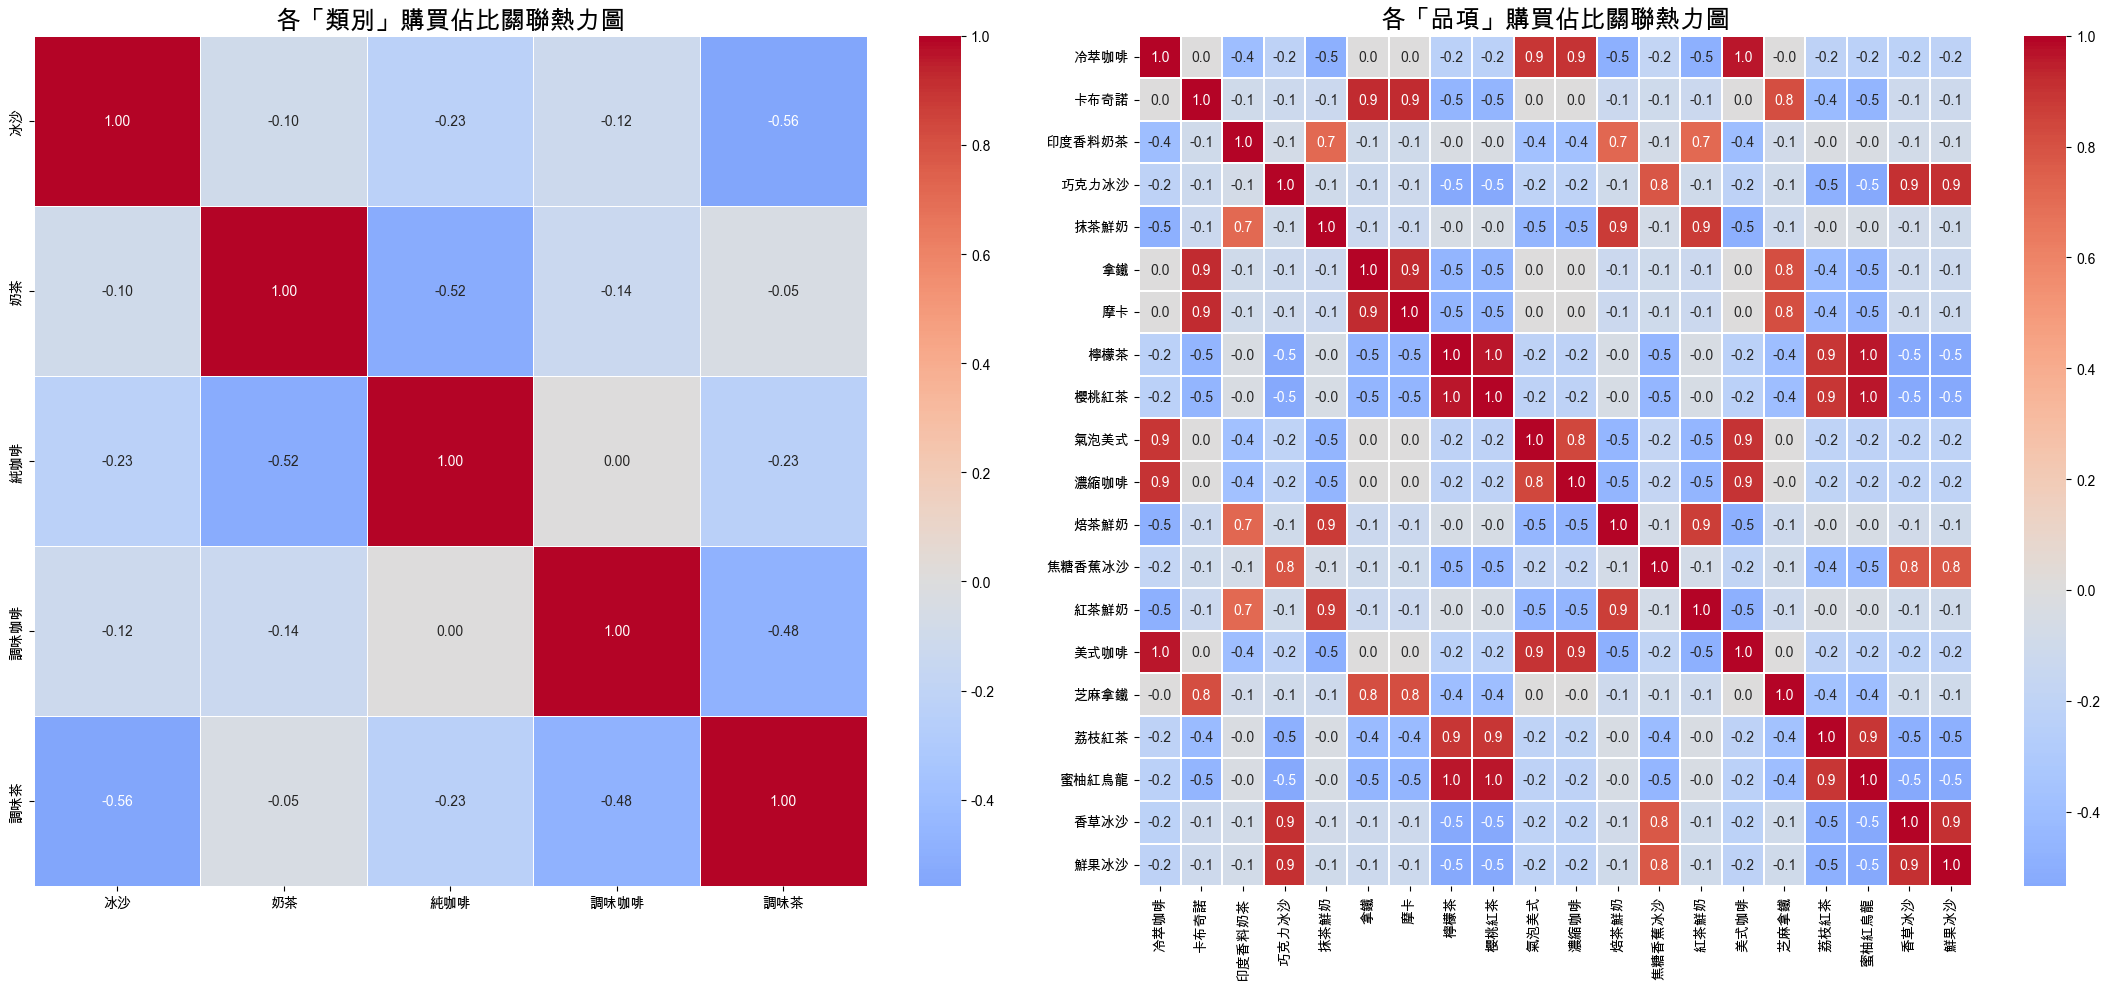

In [12]:
# ==========================================
# 繪製「類別」與「品項」熱力圖
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# ------------------------------------
# 圖表一：各「類別」關聯熱力圖
# ------------------------------------
cat_columns = [col for col in customer_data.columns if col.startswith('類別_')]
cat_data = customer_data[cat_columns].copy()
cat_data.columns = [col.replace('類別_', '') for col in cat_data.columns]

sns.heatmap(
    cat_data.corr(), 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    fmt='.2f', 
    linewidths=0.5, 
    ax=axes[0]
)
axes[0].set_title('各「類別」購買佔比關聯熱力圖', fontsize=18)

# ------------------------------------
# 圖表二：各「品項」關聯熱力圖
# ------------------------------------
prod_columns = [col for col in customer_data.columns if col.startswith('品項_')]
prod_data = customer_data[prod_columns].copy()
prod_data.columns = [col.replace('品項_', '') for col in prod_data.columns]

sns.heatmap(
    prod_data.corr(), 
    annot=True, 
    fmt='.1f',
    cmap='coolwarm', 
    center=0, 
    linewidths=0.1, 
    ax=axes[1]
)
axes[1].set_title('各「品項」購買佔比關聯熱力圖', fontsize=18)
# 因為品項文字較多，把 X 軸與 Y 軸的字體稍微調小
axes[1].tick_params(axis='x', labelsize=10, rotation=90)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()


### Findings
1. 強負相關：「冰沙」與「調味茶」(-0.56)、「純咖啡」與「奶茶」(-0.52) 具有明顯的負相關 。  
解讀： 顧客的口味具有高度排他性，喜歡清爽茶類的人極少購買冰沙。

2. 強正相關：在品項圖中，如「氣泡美式」與「冰美式」高度正相關（0.9）。
解讀： 顧客對於「基底」非常忠誠。

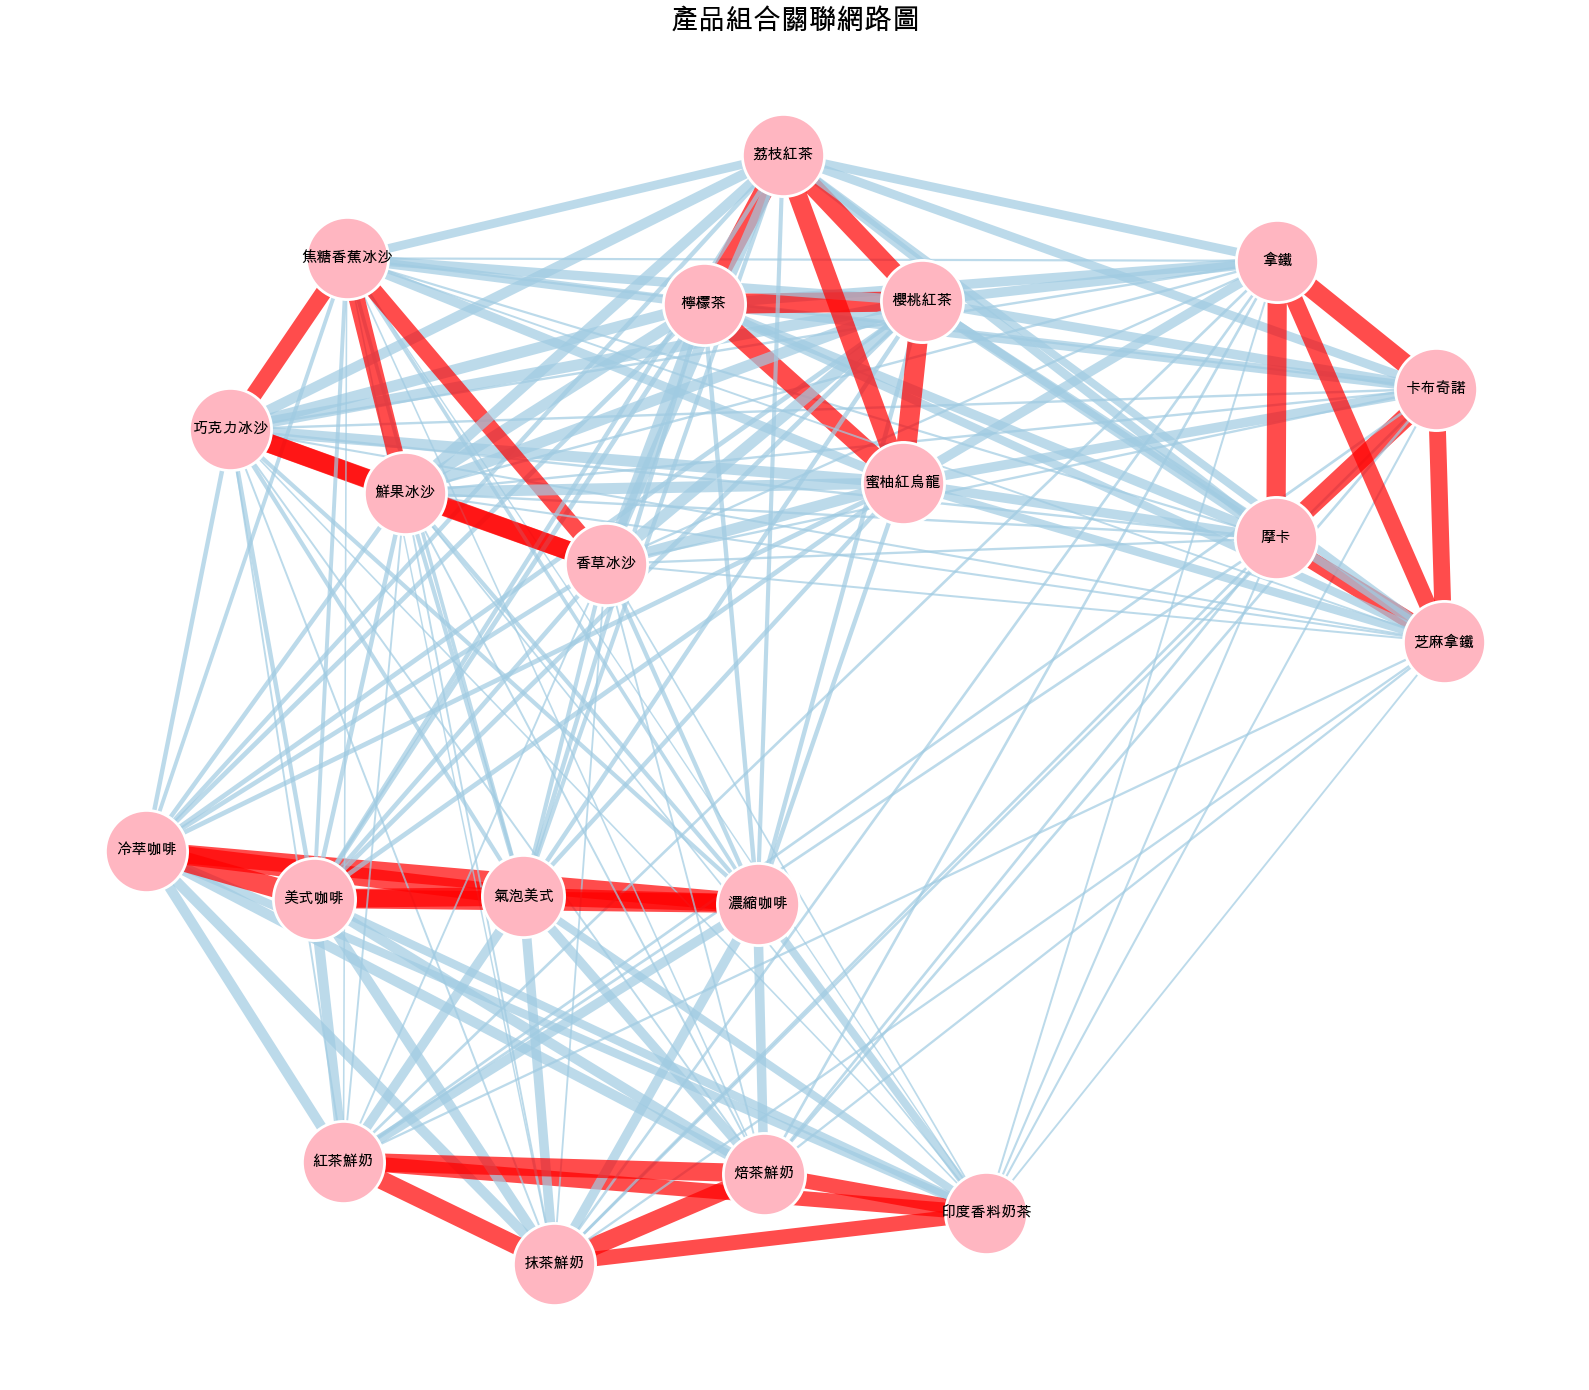

In [13]:
# 計算相關係數矩陣
corr_matrix = prod_data.corr()

# ==========================================
# 建立網路圖
# ==========================================
G = nx.Graph()

# 加入所有品項作為節點
for col in corr_matrix.columns:
    G.add_node(col)

# 建立一個門檻值，過濾掉關聯太弱的連線
threshold = 0.05 

# 加入「邊」：計算兩兩品項之間的連線
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        prod_A = corr_matrix.columns[i]
        prod_B = corr_matrix.columns[j]
        weight = corr_matrix.iloc[i, j]
        
        # 取絕對值大於門檻的作為連線，並把數值放大當作「連線粗細」
        if abs(weight) > threshold:
            # 紀錄 'corr' 屬性，保留最原始的相關係數數值以判斷正負
            G.add_edge(prod_A, prod_B, weight=abs(weight) * 15, corr=weight)

# ==========================================
# 繪製產品關聯網路圖
# ==========================================
plt.figure(figsize=(16, 14))

# 自動把「連線較粗 (關聯強)」的節點拉在一起，形成聚落
pos = nx.spring_layout(G, k=0.6, seed=42)

# 取出所有連線的權重，準備用來畫連線粗細
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# 使用迴圈判斷 'corr' 屬性，大於 0 (正相關) 給紅色，否則維持淺藍色
edge_colors = ['red' if G[u][v]['corr'] > 0 else '#A0CBE2' for u, v in edges]

# 畫出連線
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=weights, alpha=0.7)

# 畫出節點
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#FFB6C1', edgecolors='white', linewidths=2)

# 畫出文字標籤
nx.draw_networkx_labels(G, pos, font_family='Arial Unicode MS', font_size=11, font_weight='bold')

plt.title('產品組合關聯網路圖', fontsize=20)
plt.axis('off')
plt.tight_layout()
plt.show()

### Findings
1. 不同類別間的關係皆為負相關，粗線條代表兩者間有強烈的負相關。
2. 同一個類別間不同品項皆為正相關。

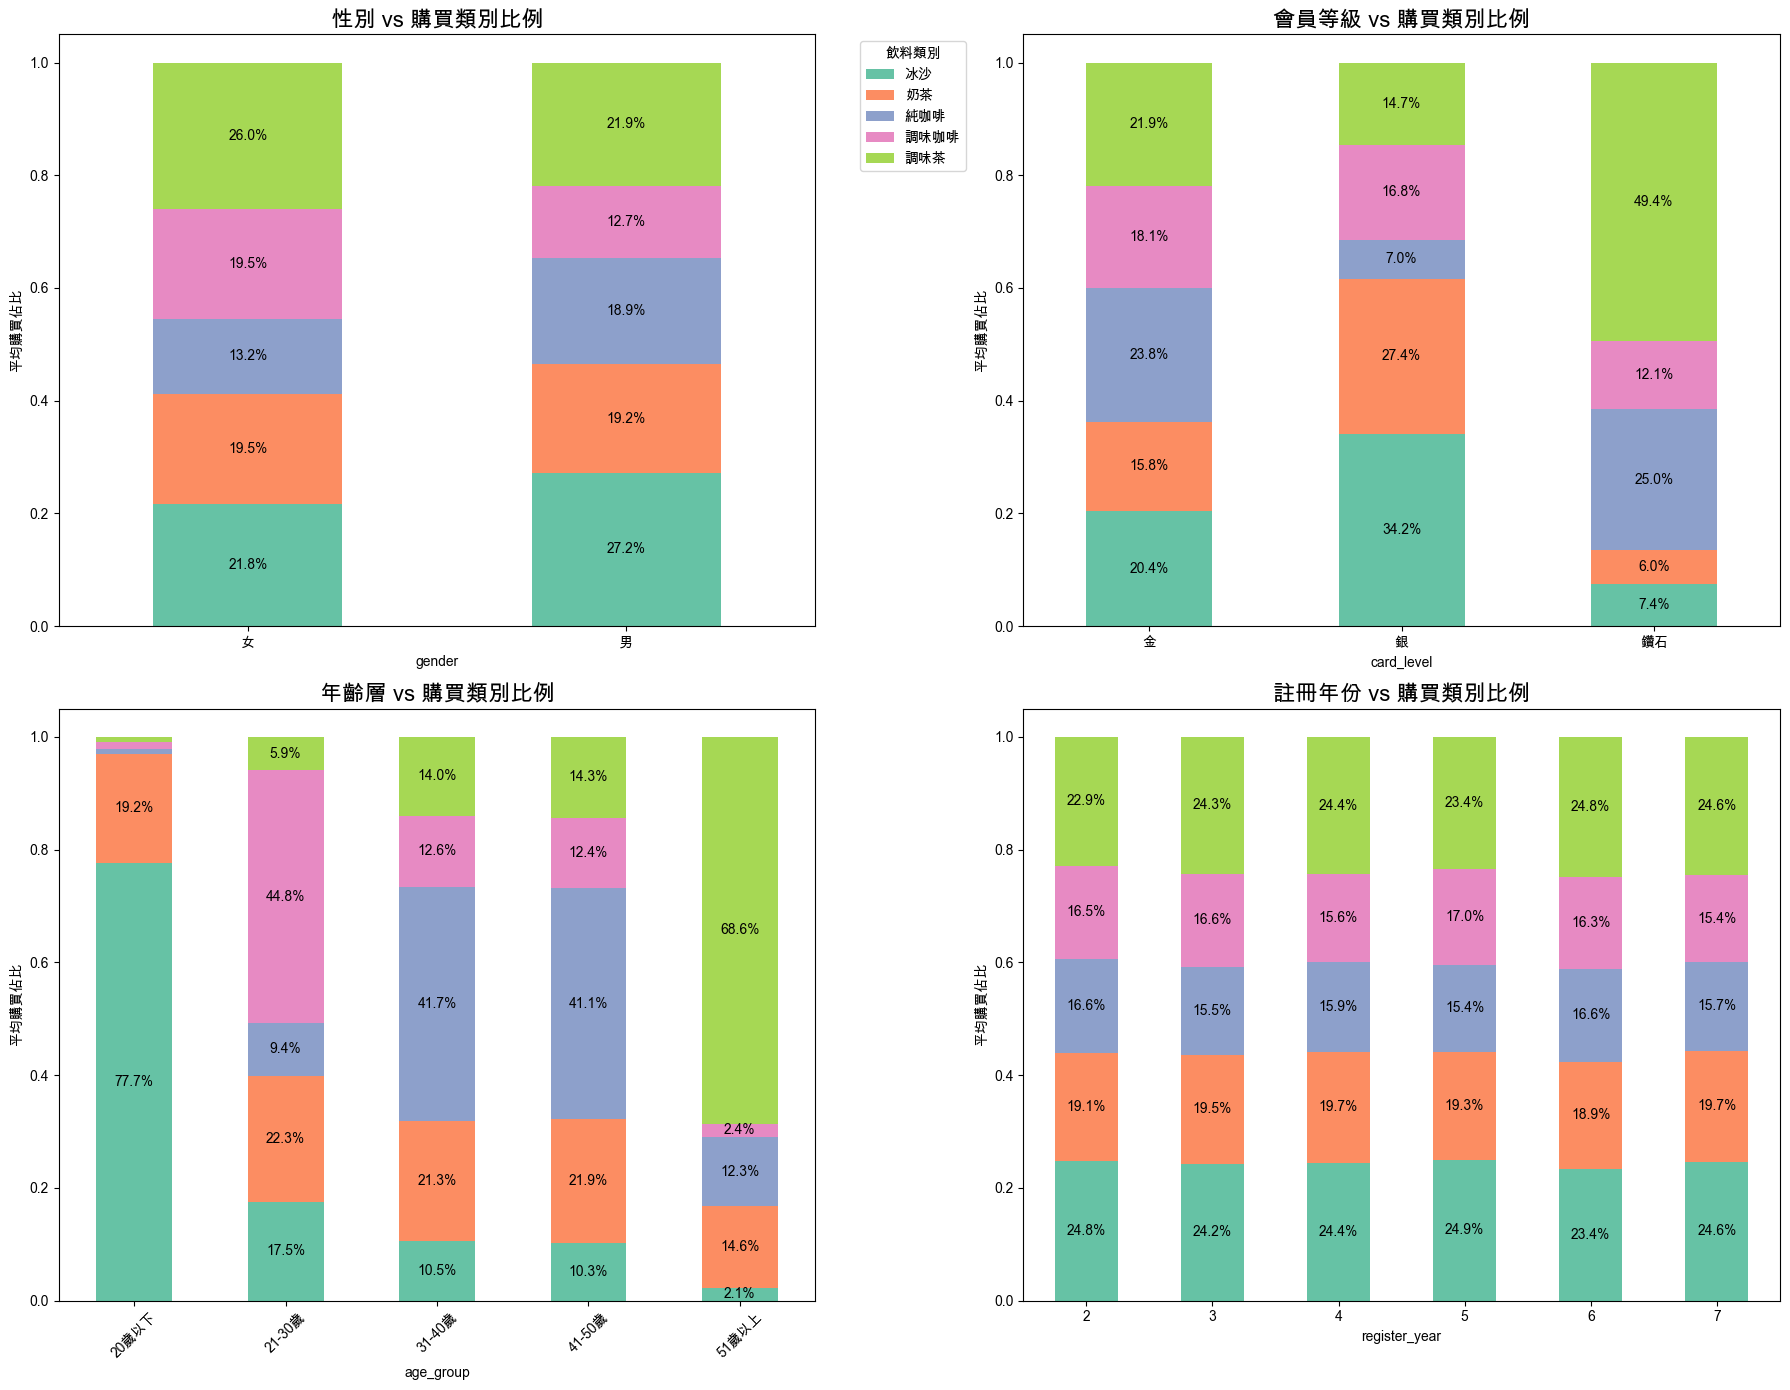

In [14]:
# ==========================================
# 1. 準備畫圖需要的資料
# ==========================================
# 自動抓取所有開頭是「類別_」的欄位名稱
cat_columns = [col for col in customer_data.columns if col.startswith('類別_')]
clean_names = [col.replace('類別_', '') for col in cat_columns]

# ==========================================
# 2. 繪製 2x2 的 100% 堆疊長條圖
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- 畫圖與換欄位名稱 ---
def plot_stacked_bar(groupby_col, ax, title, order=None):
    # 算出該群體的平均佔比
    agg_df = customer_data.groupby(groupby_col)[cat_columns].mean()
    if order and all(lvl in agg_df.index for lvl in order):
        agg_df = agg_df.reindex(order)
        
    # 把欄位名稱的「類別_」拿掉
    agg_df.columns = clean_names
    
    # 畫出堆疊圖
    agg_df.plot(kind='bar', stacked=True, ax=ax, color=global_palette)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel('平均購買佔比')

# --- 依序畫出四個象限 ---
# 左上：性別
plot_stacked_bar('gender', axes[0, 0], '性別 vs 購買類別比例')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(title='飲料類別', bbox_to_anchor=(1.05, 1), loc='upper left')

# 右上：會員等級
plot_stacked_bar('card_level', axes[0, 1], '會員等級 vs 購買類別比例', order=['金', '銀', '鑽石'])
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend_.remove() 

# 左下：年齡層
plot_stacked_bar('age_group', axes[1, 0], '年齡層 vs 購買類別比例')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend_.remove() 

# 右下：註冊年份
plot_stacked_bar('register_year', axes[1, 1], '註冊年份 vs 購買類別比例')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend_.remove() 

# ==========================================
# 3. 調整圖例排版與加上數字標籤
# ==========================================
for ax in axes.flat:
    # 疊加數字標示 (> 2% 才顯示)
    for container in ax.containers:
        labels = [f'{v.get_height()*100:.1f}%' if v.get_height() > 0.02 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=10, color='black', weight='bold')

plt.tight_layout()
plt.show()

### Findings
1. 年齡是區分客群最強力的特徵
 - Z 世代/青少年 (20 歲以下)：「冰沙狂熱者」，這群人追求口感、甜度與消暑。
 - 職場新鮮人（21-30歲）：「調味咖啡愛好者」，他們可能剛出社會，在攝取咖啡因的同時仍保有嗜甜的年輕人口味。
 - 中壯年 (31-50 歲)：「核心咖啡客」，這群人可能是職場白領，將咖啡視為機能性飲品。
 - 銀髮族 (51 歲以上)：「調味茶守護者」，對於咖啡因或乳製品的接受度可能較低。

2. 會員等級的品味差異
 - 鑽石會員：偏好非常集中在「調味茶」(49.4%) 與「純咖啡」(25%)。
 - 解讀：高價值客戶反而不偏好花俏的冰沙或奶茶。這可能代表這群人的消費目的偏向商務或高頻率的日常飲用。

3. 無顯著影響的變數
 - 註冊年份：各類別比例幾乎一致。
 - 決策：在進行 K-Means 時，可以考慮剔除註冊年份這類變數，因為它無法有效區分顧客偏好，只會增加模型的噪音。